# MRP3SAT Validator And Drawing Notebook

This notebook is self-contained: it copies the validator and plotter code directly instead of importing `validate_mrp3sat.py`.

Use it to validate YAML inputs, draw the instance, save PNG/SVG images, and run transformations one after another while keeping every visualization visible in the notebook output.

## How To Run

From `python-prototype/`:

```bash
source venv/bin/activate
pip install -r requirements.txt
jupyter notebook mrp3sat_exploration.ipynb
```

Or, without activating the venv:

```bash
venv/bin/python -m pip install -r requirements.txt
venv/bin/jupyter notebook mrp3sat_exploration.ipynb
```

In VS Code, select the interpreter/kernel from `python-prototype/venv` and run cells top to bottom.

In [1]:
from __future__ import annotations

import os
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import yaml

%matplotlib inline

In [11]:
@dataclass(frozen=True)
class Clause:
    label: str
    variables: tuple[int, int, int]
    sign: str

    @property
    def left(self) -> int:
        return min(self.variables)

    @property
    def right(self) -> int:
        return max(self.variables)


@dataclass(frozen=True)
class Instance:
    n: int
    m: int
    positive: tuple[Clause, ...]
    negative: tuple[Clause, ...]

    @property
    def clauses(self) -> tuple[Clause, ...]:
        return self.positive + self.negative


class ValidationError(Exception):
    """Raised when the input is not a valid MRP3SAT instance."""


def load_instance(path: Path | str) -> Instance:
    path = Path(path)
    try:
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle)
    except FileNotFoundError as exc:
        raise ValidationError(f"Input file not found: {path}") from exc
    except yaml.YAMLError as exc:
        raise ValidationError(f"YAML parse error: {exc}") from exc

    return parse_instance_data(data)


def parse_instance_data(data: object) -> Instance:
    if not isinstance(data, dict):
        raise ValidationError("Top-level YAML value must be a mapping.")
    raw_instance = data.get("instance")
    if not isinstance(raw_instance, dict):
        raise ValidationError("Missing required mapping: instance.")

    n = _required_int(raw_instance, "n")
    m = _required_int(raw_instance, "m")
    if n <= 0:
        raise ValidationError("instance.n must be a positive integer.")
    if m < 0:
        raise ValidationError("instance.m must be a nonnegative integer.")

    raw_positive = _required_clause_list(raw_instance, "positive")
    raw_negative = _required_clause_list(raw_instance, "negative")
    if len(raw_positive) + len(raw_negative) != m:
        raise ValidationError(
            "instance.m must equal len(instance.positive) + len(instance.negative)."
        )

    positive = tuple(
        _parse_clause(raw_clause, f"C{index}", "positive", n)
        for index, raw_clause in enumerate(raw_positive, start=1)
    )
    negative = tuple(
        _parse_clause(raw_clause, f"C{index}", "negative", n)
        for index, raw_clause in enumerate(raw_negative, start=len(positive) + 1)
    )

    return Instance(n=n, m=m, positive=positive, negative=negative)


def _required_int(mapping: dict, key: str) -> int:
    value = mapping.get(key)
    if type(value) is not int:
        raise ValidationError(f"instance.{key} must be an integer.")
    return value


def _required_clause_list(mapping: dict, key: str) -> list:
    value = mapping.get(key)
    if not isinstance(value, list):
        raise ValidationError(f"instance.{key} must be a list of clauses.")
    return value


def _parse_clause(raw_clause: object, label: str, sign: str, n: int) -> Clause:
    if not isinstance(raw_clause, list):
        raise ValidationError(f"{label} must be a list of exactly 3 variable IDs.")
    if len(raw_clause) != 3:
        raise ValidationError(f"{label} must contain exactly 3 variables.")
    if any(type(variable) is not int for variable in raw_clause):
        raise ValidationError(f"{label} must contain only integer variable IDs.")

    variables = tuple(raw_clause)
    if len(set(variables)) != 3:
        raise ValidationError(f"{label} must contain 3 distinct variables.")
    out_of_range = [variable for variable in variables if variable < 1 or variable > n]
    if out_of_range:
        bad = ", ".join(str(variable) for variable in out_of_range)
        raise ValidationError(f"{label} contains variable IDs outside 1..{n}: {bad}.")

    return Clause(label=label, variables=variables, sign=sign)


def compute_clause_levels(clauses: Iterable[Clause], side_name: str) -> dict[str, int]:
    clauses = tuple(clauses)
    by_label = {clause.label: clause for clause in clauses}
    edges: dict[str, set[str]] = {clause.label: set() for clause in clauses}
    indegree = {clause.label: 0 for clause in clauses}

    for outer in clauses:
        outer_variables = set(outer.variables)
        for inner in clauses:
            if outer == inner:
                continue
            has_blocked_connection = any(
                outer.left < variable < outer.right and variable not in outer_variables
                for variable in inner.variables
            )
            if not has_blocked_connection:
                continue
            if outer.label not in edges[inner.label]:
                edges[inner.label].add(outer.label)
                indegree[outer.label] += 1

    queue = deque(
        sorted(
            (label for label, degree in indegree.items() if degree == 0),
            key=_label_number,
        )
    )
    order: list[str] = []
    while queue:
        label = queue.popleft()
        order.append(label)
        for neighbor in sorted(edges[label], key=_label_number):
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                queue.append(neighbor)

    if len(order) != len(clauses):
        cyclic = ", ".join(
            sorted((label for label, degree in indegree.items() if degree > 0), key=_label_number)
        )
        raise ValidationError(
            f"{side_name} clauses cannot be drawn without crossings; "
            f"ordering constraints contain a cycle involving: {cyclic}."
        )

    return {label: level for level, label in enumerate(order, start=1) if label in by_label}


def _label_number(label: str) -> int:
    return int(label[1:])


def validate_instance(instance: Instance) -> tuple[dict[str, int], dict[str, int]]:
    positive_levels = compute_clause_levels(instance.positive, "Positive")
    negative_levels = compute_clause_levels(instance.negative, "Negative")
    return positive_levels, negative_levels


def summarize_instance(instance: Instance) -> None:
    print(
        f"Valid MRP3SAT instance: {instance.n} variables, "
        f"{instance.m} clauses ({len(instance.positive)} positive, "
        f"{len(instance.negative)} negative)."
    )
    for clause in instance.clauses:
        literal_prefix = "" if clause.sign == "positive" else "not "
        literals = ", ".join(f"{literal_prefix}x{variable}" for variable in clause.variables)
        print(f"{clause.label}: {literals}")

In [20]:
def draw_instance(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)

    fig_width = max(7.0, instance.n * 1.2)
    fig_height = max(4.5, (max_positive + max_negative + 2) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color="#2f2f2f", linewidth=1.2)
    axis.scatter(range(1, instance.n + 1), [0] * instance.n, color="#222222", zorder=4)
    for variable in range(1, instance.n + 1):
        axis.text(variable, -0.18, f"x{variable}", ha="center", va="top", fontsize=10)

    _draw_side(axis, instance.positive, positive_levels, direction=1, color="#2166ac")
    _draw_side(axis, instance.negative, negative_levels, direction=-1, color="#b2182b")

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(0.5, instance.n + 0.5)
    axis.set_ylim(-(max_negative + 1), max_positive + 1)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title("Monotone Rectilinear Planar 3SAT Instance")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis


def _draw_side(axis, clauses: Iterable[Clause], levels: dict[str, int], direction: int, color: str) -> None:
    for clause in clauses:
        y = direction * levels[clause.label]
        axis.plot([clause.left, clause.right], [y, y], color=color, linewidth=2.4)
        for variable in sorted(clause.variables):
            axis.plot([variable, variable], [0, y], color=color, linewidth=1.2, alpha=0.8)
            axis.scatter([variable], [y], color=color, s=18, zorder=3)
        label_y = y + (0.16 * direction)
        vertical_alignment = "bottom" if direction > 0 else "top"
        axis.text(
            (clause.left + clause.right) / 2,
            label_y,
            clause.label,
            ha="center",
            va=vertical_alignment,
            fontsize=10,
            color=color,
            fontweight="bold",
        )

## Load And Validate `input.yaml`

In [21]:
input_path = Path("input.yaml")
if not input_path.exists():
    input_path = Path("python-prototype/input.yaml")

instance = load_instance(input_path)
positive_levels, negative_levels = validate_instance(instance)
summarize_instance(instance)
print("Positive levels:", positive_levels)
print("Negative levels:", negative_levels)

Valid MRP3SAT instance: 4 variables, 4 clauses (2 positive, 2 negative).
C1: x1, x2, x4
C2: x2, x3, x4
C3: not x1, not x2, not x3
C4: not x1, not x3, not x4
Positive levels: {'C2': 1, 'C1': 2}
Negative levels: {'C3': 1, 'C4': 2}


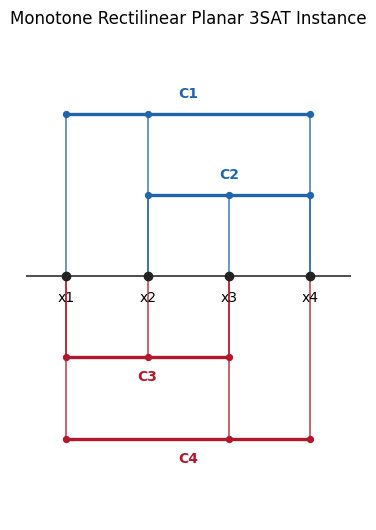

In [22]:
draw_instance(instance, positive_levels, negative_levels);

## Save The Drawing

Run either or both cells below when you want files on disk.

Saved drawing to notebook-output.png


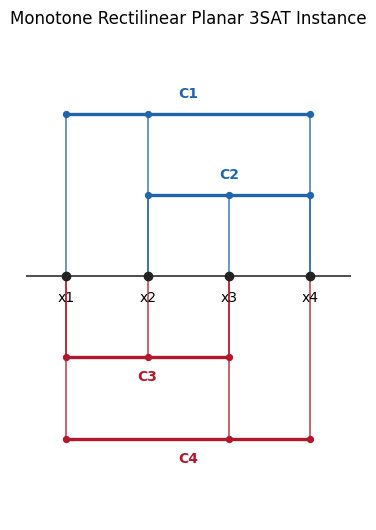

In [23]:
draw_instance(instance, positive_levels, negative_levels, output="notebook-output.png");

Saved drawing to notebook-output.svg


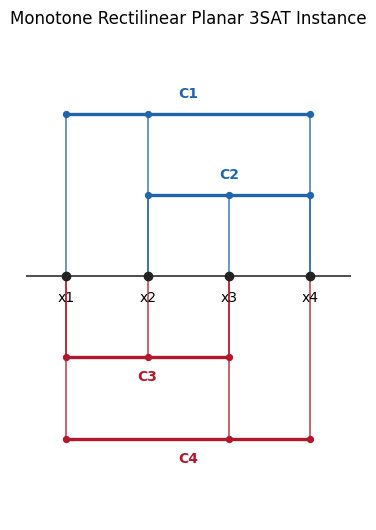

In [24]:
draw_instance(instance, positive_levels, negative_levels, output="notebook-output.svg");

## Transformation Playground

Each transformation can produce a new `Instance`, then you can validate and draw it in the next cell. This keeps every intermediate plot visible above and below.

In [25]:
def instance_to_yaml_data(instance: Instance) -> dict:
    return {
        "instance": {
            "n": instance.n,
            "m": instance.m,
            "positive": [list(clause.variables) for clause in instance.positive],
            "negative": [list(clause.variables) for clause in instance.negative],
        }
    }


def rebuild_instance(n: int, positive: list[list[int]], negative: list[list[int]]) -> Instance:
    return parse_instance_data(
        {
            "instance": {
                "n": n,
                "m": len(positive) + len(negative),
                "positive": positive,
                "negative": negative,
            }
        }
    )


def validate_and_draw(candidate: Instance, output: str | None = None):
    positive, negative = validate_instance(candidate)
    summarize_instance(candidate)
    return draw_instance(candidate, positive, negative, output=output)

Valid MRP3SAT instance: 4 variables, 4 clauses (2 positive, 2 negative).
C1: x1, x2, x4
C2: x2, x3, x4
C3: not x1, not x2, not x3
C4: not x1, not x3, not x4


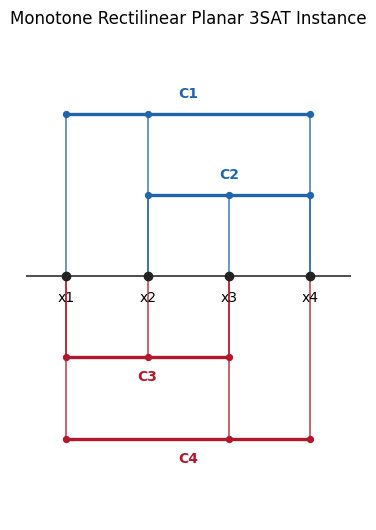

In [26]:
# Example transformation cell: edit these lists, then rerun this cell and the draw cell below.
candidate = rebuild_instance(
    n=instance.n,
    positive=[list(clause.variables) for clause in instance.positive],
    negative=[list(clause.variables) for clause in instance.negative],
)

validate_and_draw(candidate);

## Invalid Case Smoke Tests

In [27]:
invalid_cases = {
    "wrong_m": {
        "instance": {"n": 3, "m": 2, "positive": [[1, 2, 3]], "negative": []}
    },
    "bad_range": {
        "instance": {"n": 3, "m": 1, "positive": [[1, 2, 4]], "negative": []}
    },
    "duplicate": {
        "instance": {"n": 3, "m": 1, "positive": [[1, 1, 2]], "negative": []}
    },
    "short_clause": {
        "instance": {"n": 3, "m": 1, "positive": [[1, 2]], "negative": []}
    },
    "crossing_cycle": {
        "instance": {"n": 6, "m": 2, "positive": [[1, 3, 5], [2, 4, 6]], "negative": []}
    },
}

for name, data in invalid_cases.items():
    try:
        bad_instance = parse_instance_data(data)
        validate_instance(bad_instance)
    except ValidationError as exc:
        print(f"{name}: correctly invalid -> {exc}")
    else:
        print(f"{name}: unexpectedly valid")

wrong_m: correctly invalid -> instance.m must equal len(instance.positive) + len(instance.negative).
bad_range: correctly invalid -> C1 contains variable IDs outside 1..3: 4.
duplicate: correctly invalid -> C1 must contain 3 distinct variables.
short_clause: correctly invalid -> C1 must contain exactly 3 variables.
crossing_cycle: correctly invalid -> Positive clauses cannot be drawn without crossings; ordering constraints contain a cycle involving: C1, C2.
